# Data analysis of the behaviors.parquet file

### Import

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [73]:
behaviors = pd.read_parquet("./datas/ebnerd_demo/train/behaviors.parquet")

display(behaviors.head())
behaviors.info()


,impression_id,article_id,impression_time,read_time,scroll_percentage,device_type,article_ids_inview,article_ids_clicked,user_id,is_sso_user,gender,postcode,age,is_subscriber,session_id,next_read_time,next_scroll_percentage
0,48401,NaN,2023-05-21 21:06:50,21.0,NaN,2,"[9774516, 9771051, 9770028, 9775402, 9774461, ...",[9759966],22779,False,NaN,NaN,NaN,False,21,16.0,27.0
1,152513,9778745.0,2023-05-24 07:31:26,30.0,100.0,1,"[9778669, 9778736, 9778623, 9089120, 9778661, ...",[9778661],150224,False,NaN,NaN,NaN,False,298,2.0,48.0
2,155390,NaN,2023-05-24 07:30:33,45.0,NaN,1,"[9778369, 9777856, 9778500, 9778021, 9778627, ...",[9777856],160892,False,NaN,NaN,NaN,False,401,215.0,100.0
3,214679,NaN,2023-05-23 05:25:40,33.0,NaN,2,"[9776715, 9776406, 9776566, 9776071, 9776808, ...",[9776566],1001055,False,NaN,NaN,NaN,False,1357,40.0,47.0
4,214681,NaN,2023-05-23 05:31:54,21.0,NaN,2,"[9775202, 9776855, 9776688, 9771995, 9776583, ...",[9776553],1001055,False,NaN,NaN,NaN,False,1358,5.0,49.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24724 entries, 0 to 24723
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   impression_id           24724 non-null  uint32        
 1   article_id              7378 non-null   float64       
 2   impression_time         24724 non-null  datetime64[us]
 3   read_time               24724 non-null  float32       
 4   scroll_percentage       7242 non-null   float32       
 5   device_type             24724 non-null  int8          
 6   article_ids_inview      24724 non-null  object        
 7   article_ids_clicked     24724 non-null  object        
 8   user_id                 24724 non-null  uint32        
 9   is_sso_user             24724 non-null  bool          
 10  gender                  1797 non-null   float64       
 11  postcode                361 non-null    float64       
 12  age                     617 non-null    float6

In [74]:
missing = behaviors.isna().sum()
missing[missing > 0]

behaviors['impression_time'] = pd.to_datetime(behaviors['impression_time'])

behaviors['num_inview_articles'] = behaviors['article_ids_inview'].apply(lambda x: len(x) if isinstance(x, list) else 0)
behaviors['num_clicked_articles'] = behaviors['article_ids_clicked'].apply(lambda x: len(x) if isinstance(x, list) else 0)


### NaN analysis
NaN ratio for every variables :

In [75]:
behaviors.isna().sum() / len(behaviors)


impression_id             0.000000
article_id                0.701586
impression_time           0.000000
read_time                 0.000000
scroll_percentage         0.707086
device_type               0.000000
article_ids_inview        0.000000
article_ids_clicked       0.000000
user_id                   0.000000
is_sso_user               0.000000
gender                    0.927318
postcode                  0.985399
age                       0.975044
is_subscriber             0.000000
session_id                0.000000
next_read_time            0.027221
next_scroll_percentage    0.111511
num_inview_articles       0.000000
num_clicked_articles      0.000000
dtype: float64

We observe a high proportion of missing values for the following columns but we can explain it : 

article_id (70%): These NaNs occur when the impression was recorded on the front page rather than on a specific article. This is expected behavior based on the dataset documentation.

scroll_percentage (70%): Since this metric is tied to article views, it’s likely missing when the impression doesn’t correspond to a specific article (article_id is NaN), further reinforcing the front page context.

gender (93%), postcode (99%), age (98%): Just because it's not necessary to give this information therefore people don't do it.

In [76]:
# Summary of main numerical fields
behaviors[['read_time', 'scroll_percentage', 'num_inview_articles', 'num_clicked_articles']].describe()

,read_time,scroll_percentage,num_inview_articles,num_clicked_articles
count,24724.000000,7242.000000,24724.0,24724.0
mean,45.315239,99.503036,0.0,0.0
std,95.248093,5.397873,0.0,0.0
min,0.000000,9.000000,0.0,0.0
25%,12.000000,100.000000,0.0,0.0
50%,21.000000,100.000000,0.0,0.0
75%,45.000000,100.000000,0.0,0.0
max,1799.000000,100.000000,0.0,0.0


Unique users: 1590
Unique sessions: 12944
The type of device used to access the content, such as desktop (1) mobile (2), tablet (3), or unknown (0).


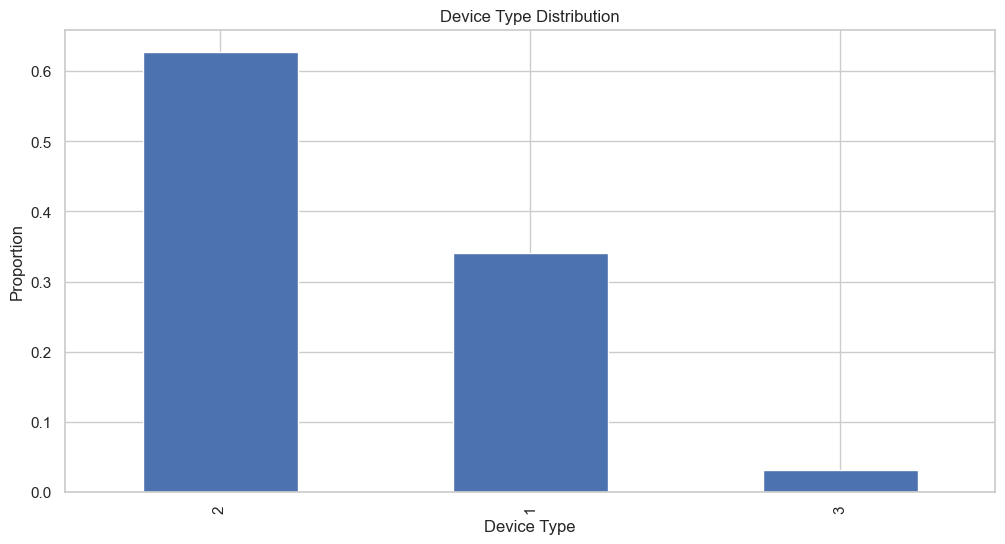

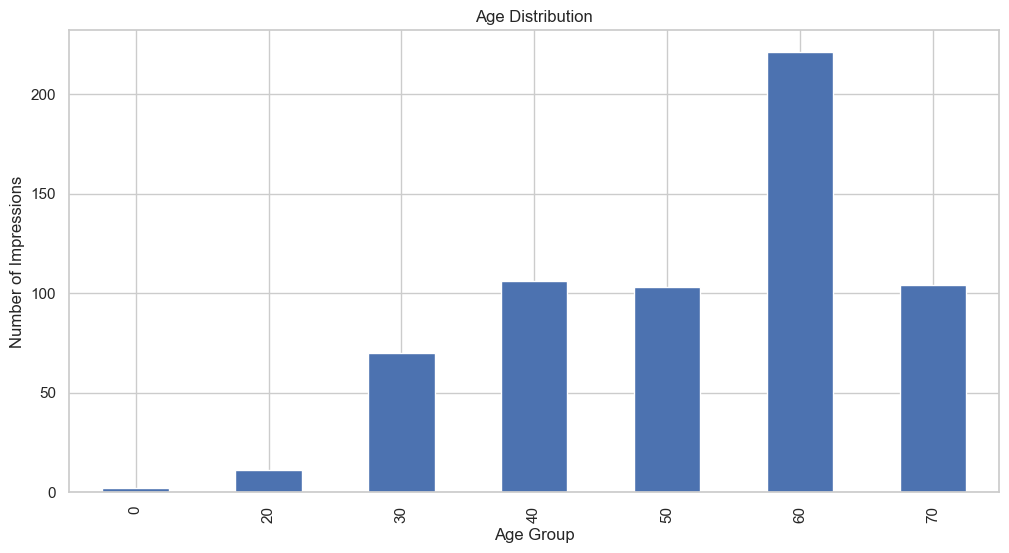

In [77]:
# 👤 Number of unique users and sessions
print(f"Unique users: {behaviors['user_id'].nunique()}")
print(f"Unique sessions: {behaviors['session_id'].nunique()}")



# Device type distribution
behaviors['device_type'].value_counts(normalize=True).plot(kind='bar', title='Device Type Distribution')
print("The type of device used to access the content, such as desktop (1) mobile (2), tablet (3), or unknown (0).")
plt.xlabel('Device Type')
plt.ylabel('Proportion')
plt.show()

# Age distribution
behaviors['age'].dropna().astype(int).value_counts().sort_index().plot(kind='bar', title='Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Impressions')
plt.show()


Most of users use a mobile or a desktop to read articles and are betxeen 40 and 70.

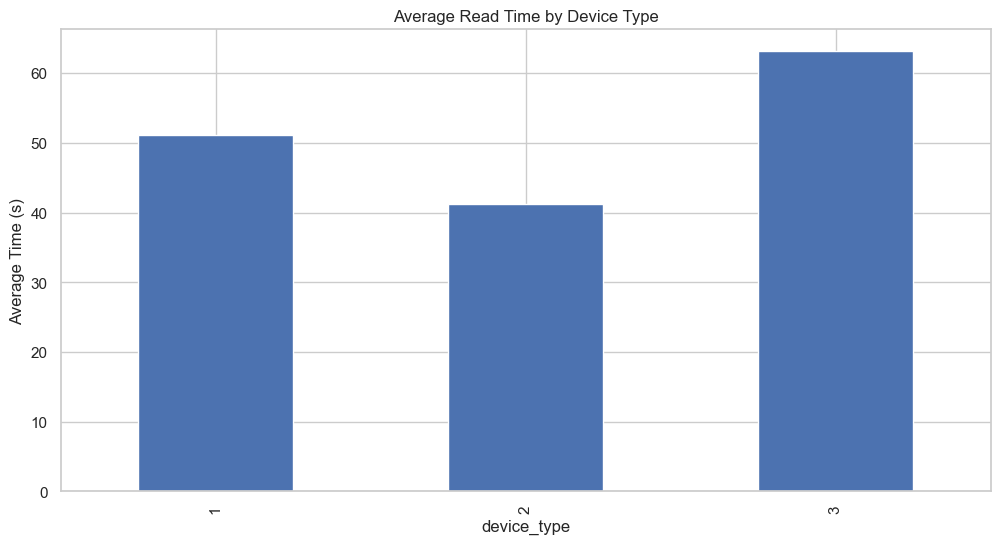

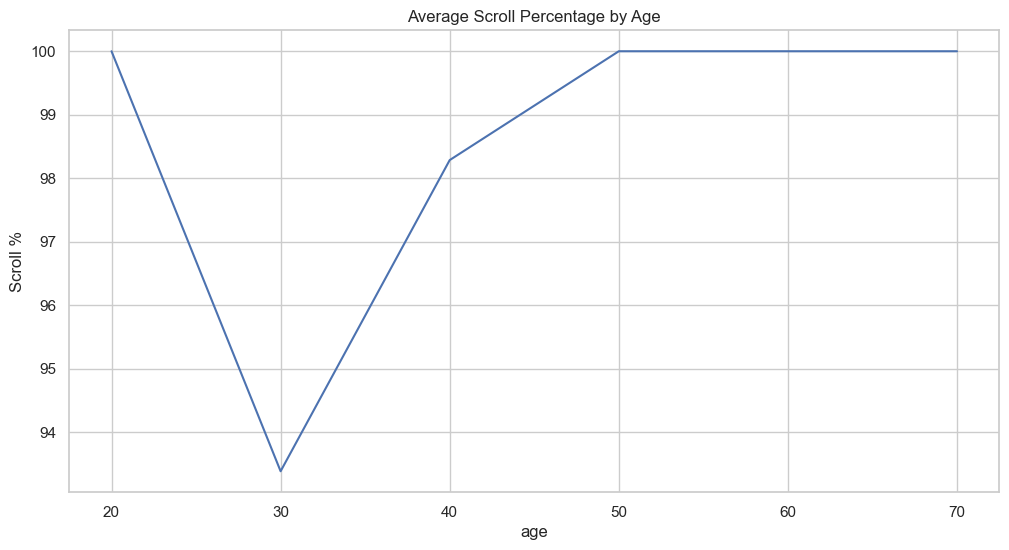

In [78]:
# 📱 Average read_time per device type
behaviors.groupby('device_type')['read_time'].mean().plot(kind='bar', title='Average Read Time by Device Type')
plt.ylabel('Average Time (s)')
plt.show()

# 🔁 Average scroll percentage by age group
behaviors.groupby('age')['scroll_percentage'].mean().plot(kind='line', title='Average Scroll Percentage by Age')
plt.ylabel('Scroll %')
plt.show()


In [79]:
# 📌 Average number of impressions per user
impressions_per_user = behaviors.groupby('user_id')['impression_id'].count()
print(f"Average impressions per user: {impressions_per_user.mean():.2f}")

# ⏱️ Average session duration
session_durations = behaviors.groupby('session_id')['impression_time'].agg(['min', 'max'])
session_durations['duration_sec'] = (session_durations['max'] - session_durations['min']).dt.total_seconds()
print(f"Average session duration: {session_durations['duration_sec'].mean():.2f} s")


Average impressions per user: 15.55
Average session duration: 87.73 s


## Variables relations analysis

### Correlation matrix


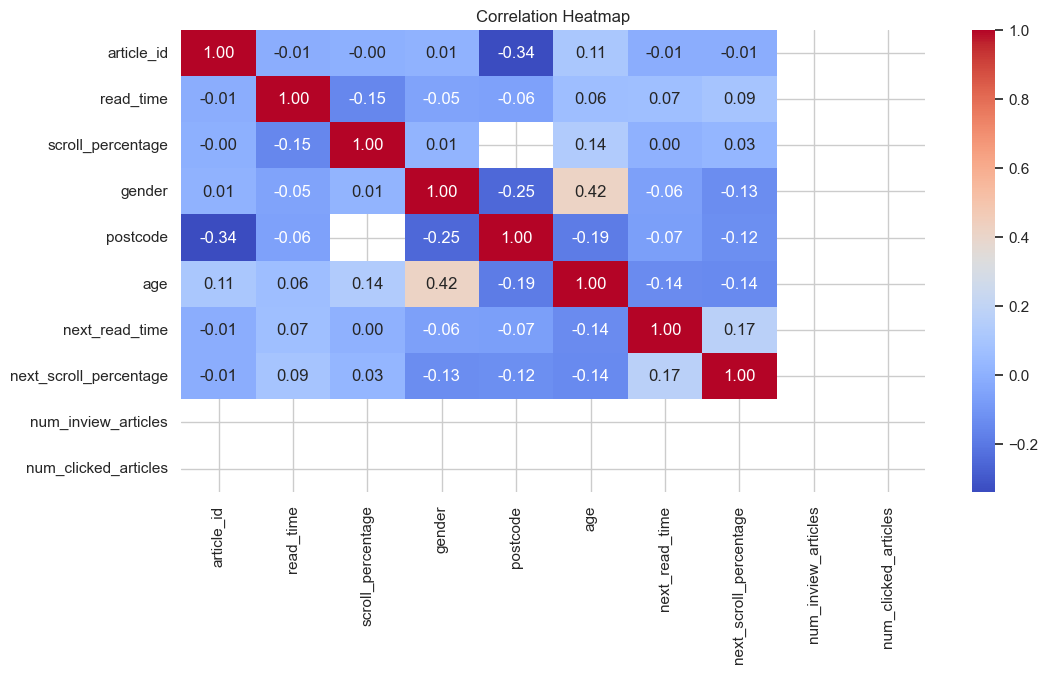

In [80]:

num_cols = behaviors.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).copy()
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


### PCA

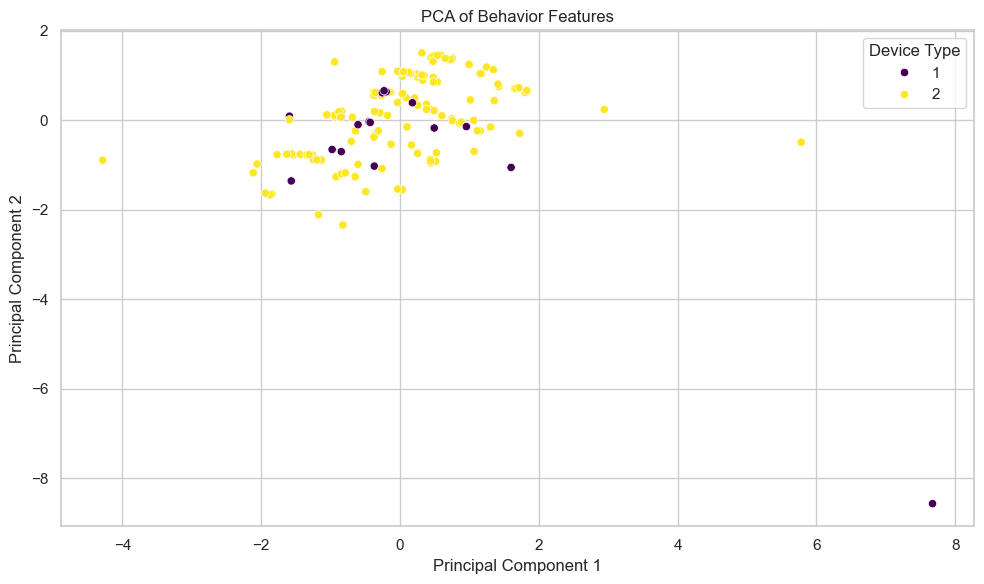

In [81]:
quantitative_cols = [
    "read_time", 
    "scroll_percentage", 
    "next_read_time", 
    "next_scroll_percentage",
    "is_sso_user", 
    "is_subscriber", 
    "age"
]

quantitative_values_df = behaviors[quantitative_cols].dropna()
scaler = StandardScaler()
quantitative_values_scaled = scaler.fit_transform(quantitative_values_df)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(quantitative_values_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['category'] = behaviors.loc[quantitative_values_df.index, 'device_type'].values

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='category', data=pca_df, palette='viridis')
plt.title('PCA of Behavior Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Device Type')
plt.tight_layout()
plt.show()
